# TCC Training & Evaluation
## Stage 2: Train embeddings, extract representations, visualize

This notebook loads the processed pouring dataset (from local disk or S3),
trains TCC models at multiple embedding dimensions, and produces
trajectory visualizations and segmentation analysis.

**Prerequisite:** Run `make data-prep` first (or `tcc_data_prep.ipynb`).

**Config:** Uses the same `configs/pouring.yaml` as the data-prep notebook.

**Usage:**
```bash
make train
make train NB_PARAMS="-p max_iters 10000"
```

In [1]:
import sys
import os
import pathlib
import subprocess

IN_COLAB = "google.colab" in sys.modules

print("Python:", sys.version)
print("Running in Colab:", IN_COLAB)

Python: 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]
Running in Colab: False


In [2]:
if IN_COLAB:
    REPO_DIR = pathlib.Path("tcc")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/aegean-ai/tcc", str(REPO_DIR)], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-e", "./tcc[notebooks]"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "matplotlib", "scikit-learn", "umap-learn", "tqdm"], check=True)
else:
    print("Skipping clone/install \u2014 running inside dev container.")

Skipping clone/install — running inside dev container.


In [3]:
# \u2500\u2500 Papermill parameters \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
config_path = "configs/pouring.yaml"
embed_dims = [32, 64, 128]
max_iters = 5000
wandb_enabled = True
wandb_project = "eng-ai-agents"

In [4]:
from tcc.storage import load_storage_config

storage = load_storage_config(config_path)

# Resolve the path that the training code will use.
# For local: direct path to processed_dir parent.
# For S3: download to cache_dir first, then point training at cache.
if storage.storage_backend == "s3":
    import fsspec

    fs = fsspec.filesystem("s3", **storage.s3_storage_options)
    cache_root = pathlib.Path(storage.cache_dir) / "processed" / storage.dataset_name
    cache_root.parent.mkdir(parents=True, exist_ok=True)

    print(f"Downloading processed data from {storage.processed_dir} -> {cache_root}")
    fs.get(storage.processed_dir, str(cache_root), recursive=True)

    DATASET_ROOT = cache_root.parent  # parent of "pouring/" dir
    print(f"Dataset root: {DATASET_ROOT.resolve()}")
else:
    DATASET_ROOT = pathlib.Path(storage.processed_dir).parent
    print(f"Dataset root (local): {DATASET_ROOT.resolve()}")

# Verify data exists
dataset_dir = DATASET_ROOT / storage.dataset_name
assert dataset_dir.exists(), f"Dataset not found at {dataset_dir}. Run data-prep first."
splits = [d.name for d in dataset_dir.iterdir() if d.is_dir()]
print(f"Found splits: {splits}")

Dataset root: /workspaces/tcc/data/pouring_cache/processed
Found splits: ['green_to_white5_fake_view0', 'crystal_to_white5_fake_view0', 'creamsoda_to_clear1_real_view0', 'milk_to_clear99_real_view1', 'pom_to_white4_fake_view1', 'tea_to_clear1_fake_view1', 'clearodwalla_to_white_real_view0', 'green_to_white1_real_view1', 'whiteorange_to_clear0_real_view0', 'whitesoda_to_clear106_real_view0', 'tea_to_clear1_fake_view0', 'crystal_to_clear1_fake_view1', 'metallic_to_white6_fake_view1', 'crystal_to_clear_real_view1', 'creamsoda_to_clear5_real_view0', 'whiteorange_to_clear1_real_view0', 'green_to_clear1_fake_view0', 'whiteodwalla_to_clear0_real_view1', 'clearbottle_to_clear0_real_view0', 'red_to_white2_fake_view1', 'metallic_to_clear99_real_view1', 'clearodwalla_to_clear0_real_view0', 'tea_to_clear2_fake_view0', 'clearsoda_to_white1_real_view1', 'box_to_white1_fake_view0', 'crystal_to_clear1_real_view1', 'tea_to_clear_real_view1', 'red_to_clear99_real_view0', 'crystal_to_white1_real_view0', 

In [5]:
EXPERIMENT_ROOT = pathlib.Path("runs_tutorial")
EXPERIMENT_ROOT.mkdir(exist_ok=True)

print("Experiments stored in:", EXPERIMENT_ROOT.resolve())
print("Embedding dims:", embed_dims)
print("Max iterations:", max_iters)

Experiments stored in: /workspaces/tcc/runs_tutorial
Embedding dims: [32, 64, 128]
Max iterations: 5000


In [6]:
WANDB_ENABLED = wandb_enabled
WANDB_PROJECT = wandb_project
WANDB_ENTITY = ""

if WANDB_ENABLED:
    try:
        import wandb
        print("wandb version:", wandb.__version__)
        print(f"W&B logging is ENABLED (project={WANDB_PROJECT})")
    except ImportError:
        print("wandb not installed \u2014 disabling W&B logging.")
        WANDB_ENABLED = False
else:
    print("W&B logging is DISABLED.")

wandb version: 0.25.1
W&B logging is ENABLED (project=eng-ai-agents)


In [7]:
def set_if_exists(obj, path, value):
    parts = path.split(".")
    cur = obj
    for p in parts[:-1]:
        if not hasattr(cur, p):
            return False
        cur = getattr(cur, p)
    if hasattr(cur, parts[-1]):
        setattr(cur, parts[-1], value)
        return True
    return False

def get_if_exists(obj, path, default=None):
    parts = path.split(".")
    cur = obj
    for p in parts:
        if not hasattr(cur, p):
            return default
        cur = getattr(cur, p)
    return cur

In [8]:
def make_run_config(embed_dim=128, max_iters=5000, logdir=None):
    from tcc.config import get_default_config

    cfg = get_default_config()

    set_if_exists(cfg, "training_algo", "alignment")
    set_if_exists(cfg, "datasets", [storage.dataset_name])
    set_if_exists(cfg, "train.max_iters", max_iters)
    set_if_exists(cfg, "model.conv_embedder.embedding_size", embed_dim)

    ds_fmt = str((DATASET_ROOT / "%s").resolve())
    set_if_exists(cfg, "path_to_tfrecords", ds_fmt)

    if logdir is None:
        logdir = str((EXPERIMENT_ROOT / f"pouring_tcc_d{embed_dim}").resolve())
    set_if_exists(cfg, "logdir", logdir)

    set_if_exists(cfg, "logging.wandb_enabled", WANDB_ENABLED)
    set_if_exists(cfg, "logging.wandb_project", WANDB_PROJECT)
    set_if_exists(cfg, "logging.wandb_entity", WANDB_ENTITY)
    set_if_exists(cfg, "logging.wandb_run_name", f"pouring_d{embed_dim}")

    return cfg

In [9]:
def summarize_config(cfg):
    keys = [
        "training_algo",
        "datasets",
        "path_to_tfrecords",
        "logdir",
        "train.batch_size",
        "train.max_iters",
        "train.num_frames",
        "eval.batch_size",
        "model.embedder_type",
        "model.conv_embedder.embedding_size",
        "model.base_model.train_base",
        "optimizer.type",
        "optimizer.lr.initial_lr",
        "data.image_size",
        "data.frame_stride",
        "data.num_steps",
    ]
    rows = []
    for k in keys:
        rows.append((k, get_if_exists(cfg, k)))
    return rows

try:
    demo_cfg = make_run_config(embed_dim=64, max_iters=500)
    for k, v in summarize_config(demo_cfg):
        print(f"{k:40s} {v}")
    print(f"{'logging.wandb_enabled':40s} {get_if_exists(demo_cfg, 'logging.wandb_enabled')}")
    print(f"{'logging.wandb_project':40s} {get_if_exists(demo_cfg, 'logging.wandb_project')}")
except Exception as e:
    print("Config construction failed:", repr(e))

training_algo                            alignment
datasets                                 ['pouring']
path_to_tfrecords                        /workspaces/tcc/data/pouring_cache/processed/%s
logdir                                   /workspaces/tcc/runs_tutorial/pouring_tcc_d64
train.batch_size                         2
train.max_iters                          500
train.num_frames                         20
eval.batch_size                          2
model.embedder_type                      conv
model.conv_embedder.embedding_size       64
model.base_model.train_base              only_bn
optimizer.type                           adam
optimizer.lr.initial_lr                  0.0001
data.image_size                          224
data.frame_stride                        15
data.num_steps                           2
logging.wandb_enabled                    True
logging.wandb_project                    eng-ai-agents


## 6. Training

The training loop in the repo is exposed through `tcc.train.train(cfg)`.

The logic is:

1. instantiate the algorithm corresponding to `cfg.training_algo`
2. build the dataset loader
3. optimize the alignment loss
4. save checkpoints in `cfg.logdir`

In [10]:
def run_training(cfg):
    from tcc.train import train
    print("Starting training with logdir:", cfg.logdir)
    train(cfg)

# Debug run \u2014 short iteration count to verify the pipeline works
cfg_debug = make_run_config(embed_dim=32, max_iters=50)
run_training(cfg_debug)

Starting training with logdir: /workspaces/tcc/runs_tutorial/pouring_tcc_d32


wandb: Tracking run with wandb version 0.25.1


wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /workspaces/tcc/runs_tutorial/pouring_tcc_d32/wandb/offline-run-20260317_122400-1p9c7oxp


wandb: WARNING URL not available in offline run


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/vscode/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


...

 85%|████████▍ | 83.0M/97.8M [00:00<00:00, 107MB/s]

 96%|█████████▌| 93.5M/97.8M [00:00<00:00, 108MB/s]

100%|██████████| 97.8M/97.8M [00:00<00:00, 105MB/s]

wandb: You can sync this run to the cloud by running:
wandb: wandb sync /workspaces/tcc/runs_tutorial/pouring_tcc_d32/wandb/offline-run-20260317_122400-1p9c7oxp


wandb: Find logs at: ./runs_tutorial/pouring_tcc_d32/wandb/offline-run-20260317_122400-1p9c7oxp/logs


### 6.1 Full assignment runs

Run three experiments:

- $D=32$
- $D=64$
- $D=128$

In [11]:
for d in embed_dims:
    cfg_run = make_run_config(embed_dim=d, max_iters=max_iters)
    run_training(cfg_run)

wandb: Tracking run with wandb version 0.25.1


wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /workspaces/tcc/runs_tutorial/pouring_tcc_d32/wandb/offline-run-20260317_122404-rdue99xl


Starting training with logdir: /workspaces/tcc/runs_tutorial/pouring_tcc_d32


wandb: WARNING URL not available in offline run


wandb: You can sync this run to the cloud by running:
wandb: wandb sync /workspaces/tcc/runs_tutorial/pouring_tcc_d32/wandb/offline-run-20260317_122404-rdue99xl


...

wandb: Tracking run with wandb version 0.25.1


wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /workspaces/tcc/runs_tutorial/pouring_tcc_d128/wandb/offline-run-20260317_122407-k17sfvo3


wandb: WARNING URL not available in offline run


wandb: You can sync this run to the cloud by running:
wandb: wandb sync /workspaces/tcc/runs_tutorial/pouring_tcc_d128/wandb/offline-run-20260317_122407-k17sfvo3


wandb: Find logs at: ./runs_tutorial/pouring_tcc_d128/wandb/offline-run-20260317_122407-k17sfvo3/logs


## 7. Loading checkpoints and extracting embeddings

The repo provides the pieces we need:

- `get_algo(...)` to instantiate the TCC algorithm
- checkpoint loading utilities from `tcc.train`
- embedding extraction utilities from `tcc.evaluate`

In [12]:
import torch
from pathlib import Path

def latest_checkpoint(logdir):
    candidates = sorted(Path(logdir).glob("checkpoint_*.pt"))
    if not candidates:
        return None
    return str(candidates[-1])

def load_trained_algo(cfg, checkpoint_path=None):
    from tcc.algos.registry import get_algo
    from tcc.train import load_checkpoint

    algo = get_algo(cfg.training_algo, cfg=cfg)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    algo = algo.to(device)

    if checkpoint_path is None:
        checkpoint_path = latest_checkpoint(cfg.logdir)

    if checkpoint_path is None:
        raise FileNotFoundError(f"No checkpoint found in {cfg.logdir}")

    _ = load_checkpoint(checkpoint_path, algo, optimizer=None)
    algo.eval()
    return algo, device, checkpoint_path

### 7.1 Build the evaluation dataloader

The repo training code internally converts the top-level config into a `DataConfig`.
We reuse the same helper if available; otherwise we build the `DataConfig` manually.

In [13]:
def make_eval_dataloader(cfg, split="val", mode="eval"):
    """Build an evaluation dataloader from the top-level config.

    Uses the repo's internal _build_data_config helper.  If that helper
    is missing or its signature has changed, the call fails loudly so
    you know the notebook and repo are out of sync.
    """
    from tcc.datasets import create_dataset

    try:
        from tcc.train import _build_data_config
    except ImportError:
        raise ImportError(
            "Cannot import _build_data_config from tcc.train. "
            "The aegean-ai/tcc repo API may have changed. "
            "Check the repo README for the current evaluation interface."
        )

    data_cfg = _build_data_config(cfg)
    loader = create_dataset(split=split, mode=mode, config=data_cfg)
    return loader

In [14]:
def extract_embeddings_for_run(cfg, split="val", max_embs=0):
    """Extract embeddings from a trained checkpoint.

    Args:
        cfg: TCCConfig for the run.
        split: dataset split to evaluate ("val" or "train").
        max_embs: maximum number of video embeddings to extract.
                  0 means extract all available videos (no limit).
    """
    from tcc.evaluate import get_embeddings_dataset

    algo, device, checkpoint_path = load_trained_algo(cfg)
    loader = make_eval_dataloader(cfg, split=split, mode="eval")
    bundle = get_embeddings_dataset(algo, loader, device=device, max_embs=max_embs)

    print("Loaded checkpoint:", checkpoint_path)
    print("Videos:", len(bundle["embeddings_list"]))
    print("Flat embeddings shape:", bundle["embeddings"].shape)
    return bundle

# Example:
# cfg64 = make_run_config(embed_dim=64, max_iters=5000)
# emb_bundle = extract_embeddings_for_run(cfg64, split="val")

## 8. Representation diagnostics

Now we test the main scientific claim:

> Do embeddings organize frames by **task phase**?

We use two projection methods and two diagnostic approaches:

1. **PCA** \u2014 linear projection preserving global variance; fast and deterministic
2. **UMAP** \u2014 nonlinear projection revealing manifold structure; better for fine-grained phase separation

For each, we produce:

- **single-video trajectory plots** colored by time
- **cross-video overlays** in a shared projection space (joint fit, so coordinates are comparable)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

def project_pca(Z):
    return PCA(n_components=2).fit_transform(Z)

def project_umap(Z, seed=0):
    if not HAS_UMAP:
        raise ImportError("Install umap-learn: pip install umap-learn")
    return umap.UMAP(n_components=2, random_state=seed).fit_transform(Z)

def project(Z, method="umap", seed=0):
    if method == "pca":
        return project_pca(Z)
    if method == "umap":
        return project_umap(Z, seed=seed)
    raise ValueError(f"Unknown method: {method}. Use 'pca' or 'umap'.")

/workspaces/tcc/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
def plot_single_trajectory(Z, method="umap", title=None):
    Y = project(Z, method=method)
    t = np.arange(len(Y))

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(Y[:, 0], Y[:, 1], c=t, s=12)
    plt.colorbar(sc, label="time")
    plt.xlabel("component 1")
    plt.ylabel("component 2")
    plt.title(title or f"{method.upper()} trajectory")
    plt.tight_layout()
    plt.show()

def plot_multiple_trajectories(embeddings_list, names=None, method="umap", max_videos=6):
    """Plot cross-video trajectories in a shared projection space.

    All video embeddings are concatenated, projected once, then split
    back so that the 2D coordinates are comparable across videos.
    """
    n = min(max_videos, len(embeddings_list))
    selected = embeddings_list[:n]
    lengths = [len(Z) for Z in selected]
    Z_all = np.concatenate(selected, axis=0)

    Y_all = project(Z_all, method=method, seed=0)

    splits = np.cumsum(lengths[:-1])
    Y_per_video = np.split(Y_all, splits)

    plt.figure(figsize=(7, 6))
    for i, Y in enumerate(Y_per_video):
        label = names[i] if names else f"video_{i}"
        plt.plot(Y[:, 0], Y[:, 1], alpha=0.8, label=label)
    plt.xlabel("component 1")
    plt.ylabel("component 2")
    plt.title(f"{method.upper()} cross-video trajectories (joint projection)")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

Loaded checkpoint: /workspaces/tcc/runs_tutorial/pouring_tcc_d64/checkpoint_5000.pt
Videos: 470
Flat embeddings shape: (9400, 128)


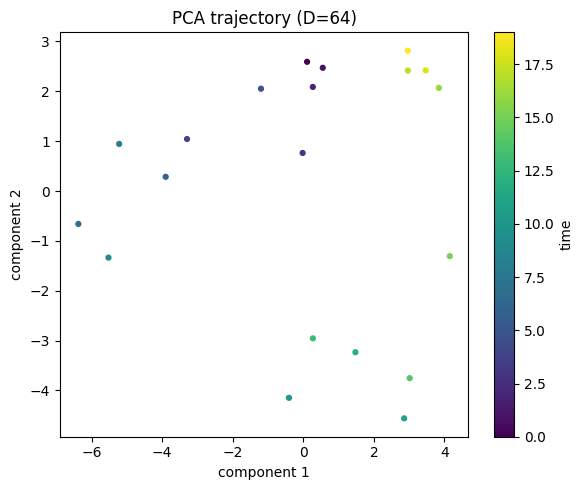

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


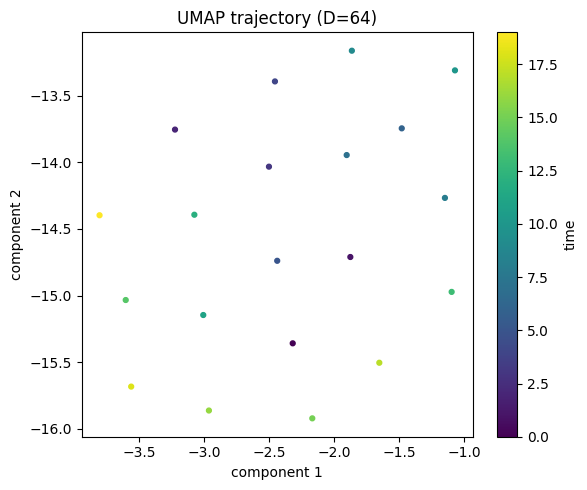

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


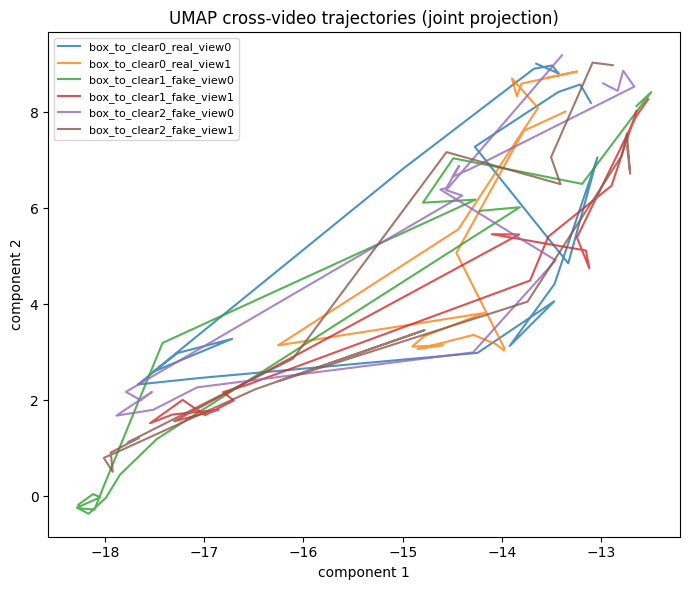

In [17]:
emb_bundle = extract_embeddings_for_run(make_run_config(embed_dim=64, max_iters=max_iters), split="val")
Z0 = emb_bundle["embeddings_list"][0]
plot_single_trajectory(Z0, method="pca", title="PCA trajectory (D=64)")
plot_single_trajectory(Z0, method="umap", title="UMAP trajectory (D=64)")
plot_multiple_trajectories(emb_bundle["embeddings_list"], emb_bundle.get("names"), method="umap")

## 9. Temporal segmentation from embedding geometry

This section operationalizes the claim that the embedding has learned latent phase.

We use two complementary segmentation strategies:

### 9.1 Change-point detection

If the representation changes rapidly at phase transitions, then
$$
d_t = \|z_t - z_{t-1}\|
$$
should spike near boundaries. This is a **boundary-detection** approach \u2014 it finds *where* phase transitions occur without assigning cluster labels.

### 9.2 KMeans clustering in the native embedding space

If the embedding clusters by phase, KMeans should recover coarse phase labels. We use $k=6$ to match the six expected pouring phases (reach, grasp, lift, tilt, pour, retract). Experiment with different $k$ values to test sensitivity.

In [18]:
from sklearn.cluster import KMeans

def change_point_scores(Z):
    d = np.linalg.norm(Z[1:] - Z[:-1], axis=1)
    d = np.concatenate([[0.0], d])
    return d

def detect_boundaries(d, threshold_quantile=0.98, min_gap=10):
    thr = float(np.quantile(d, threshold_quantile))
    idx = np.where(d >= thr)[0].tolist()

    kept = []
    last = -10**9
    for i in idx:
        if i - last >= min_gap:
            kept.append(i)
            last = i
    return kept, thr

def cluster_kmeans(Z, k=6, seed=0):
    """KMeans with k=6 matching the six expected pouring phases."""
    return KMeans(n_clusters=k, random_state=seed, n_init="auto").fit_predict(Z)

In [19]:
def plot_segmentation(Z, labels=None, boundaries=None, title="Segmentation"):
    d = change_point_scores(Z)
    T = len(Z)

    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(T), d)
    if boundaries is not None:
        for b in boundaries:
            plt.axvline(b, linestyle="--")
    plt.title(title + " \u2014 change-point score")
    plt.xlabel("frame index")
    plt.ylabel(r"$\|z_t-z_{t-1}\|$")
    plt.tight_layout()
    plt.show()

    if labels is not None:
        plt.figure(figsize=(10, 2))
        plt.plot(np.arange(T), labels, drawstyle="steps-mid")
        if boundaries is not None:
            for b in boundaries:
                plt.axvline(b, linestyle="--")
        plt.title(title + " \u2014 cluster labels over time")
        plt.xlabel("frame index")
        plt.ylabel("cluster")
        plt.tight_layout()
        plt.show()

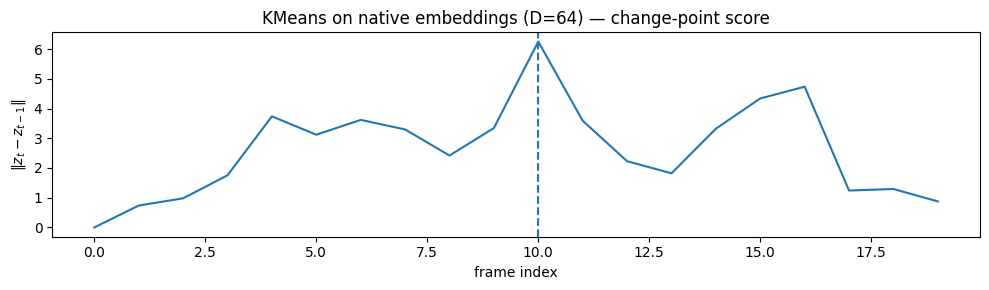

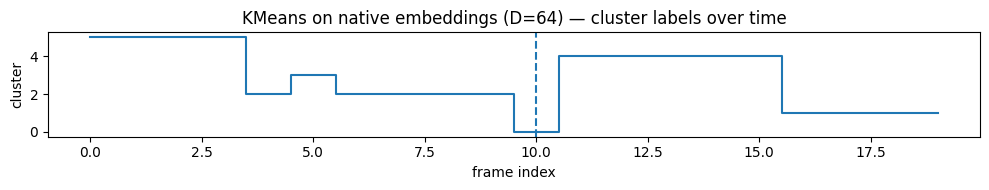

In [20]:
Z = emb_bundle["embeddings_list"][0]
d = change_point_scores(Z)
boundaries, thr = detect_boundaries(d, threshold_quantile=0.98, min_gap=8)
labels_km = cluster_kmeans(Z, k=6)

plot_segmentation(Z, labels=labels_km, boundaries=boundaries, title="KMeans on native embeddings (D=64)")

## 10. Embedding dimension sweep

The assignment asks you to compare:

- $D=32$
- $D=64$
- $D=128$

This matters because the embedding dimension controls the trade-off between:

- **compression**
- **expressiveness**
- **ease of clustering**
- **risk of overfitting appearance rather than phase**

Loaded checkpoint: /workspaces/tcc/runs_tutorial/pouring_tcc_d32/checkpoint_5000.pt
Videos: 470
Flat embeddings shape: (9400, 128)

===== Dimension 32 =====
Number of videos: 470
Flat embedding matrix: (9400, 128)


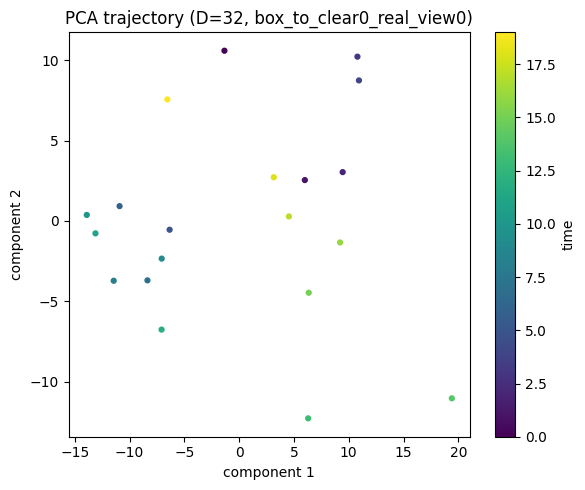

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


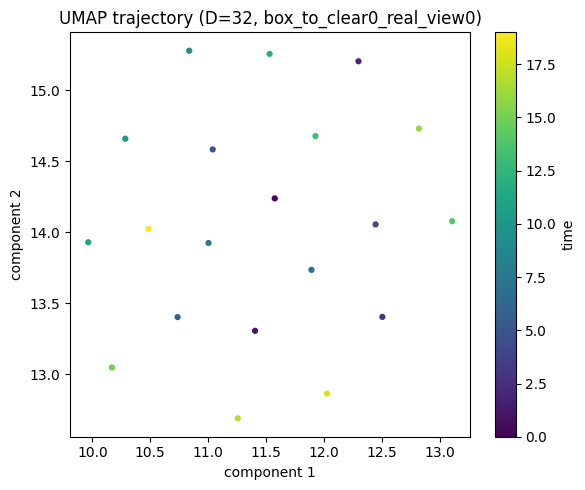

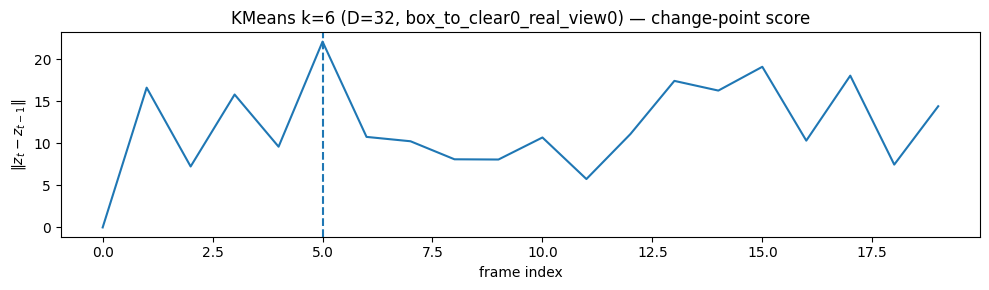

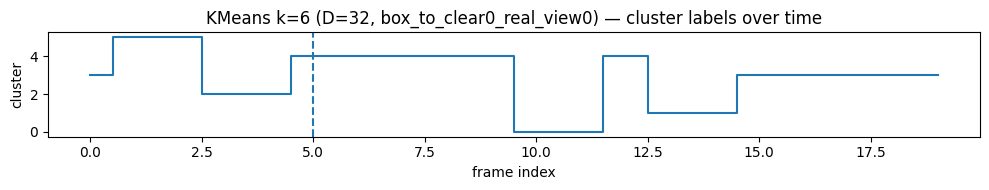

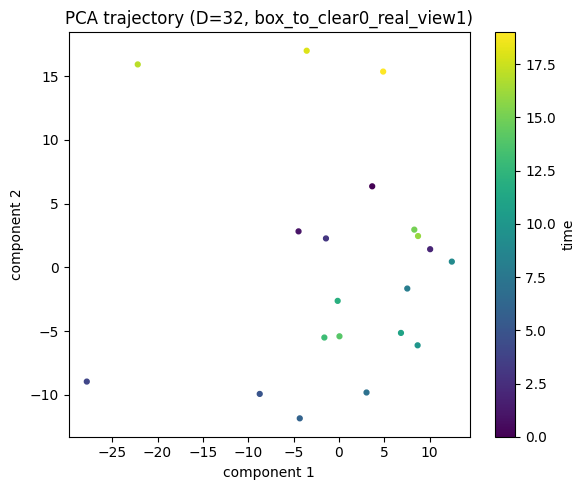

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


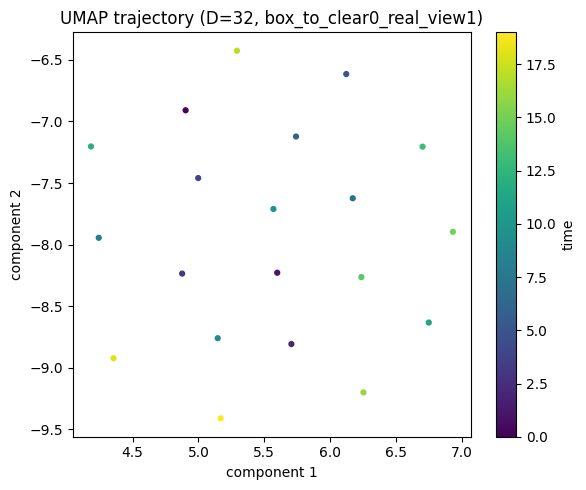

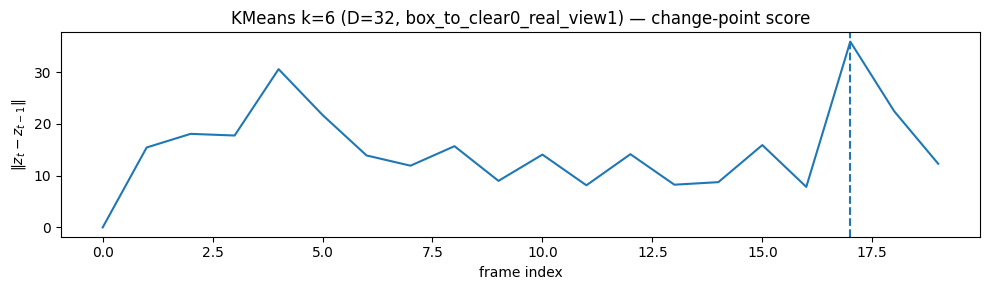

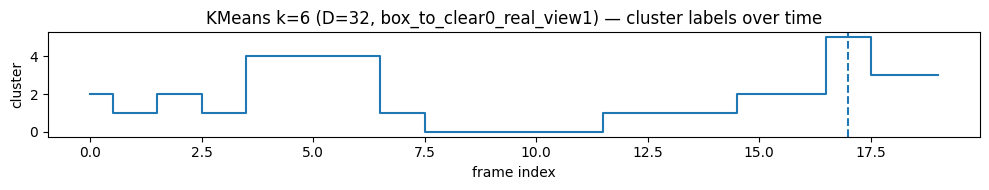

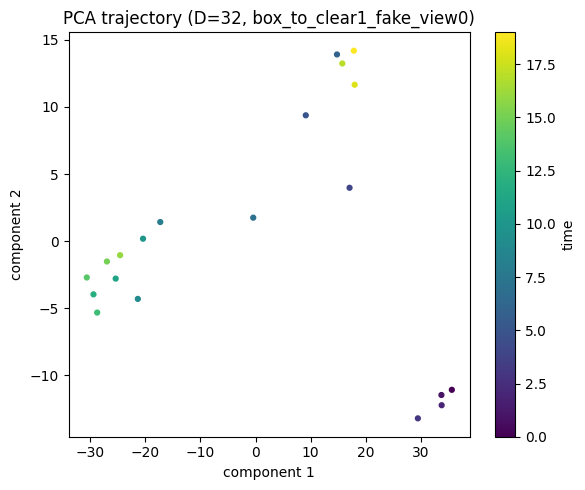

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


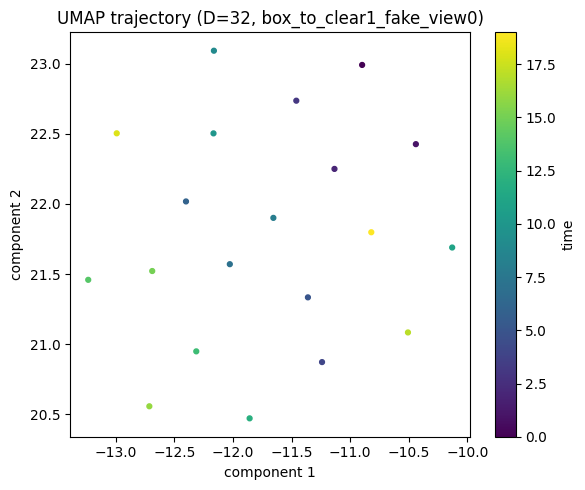

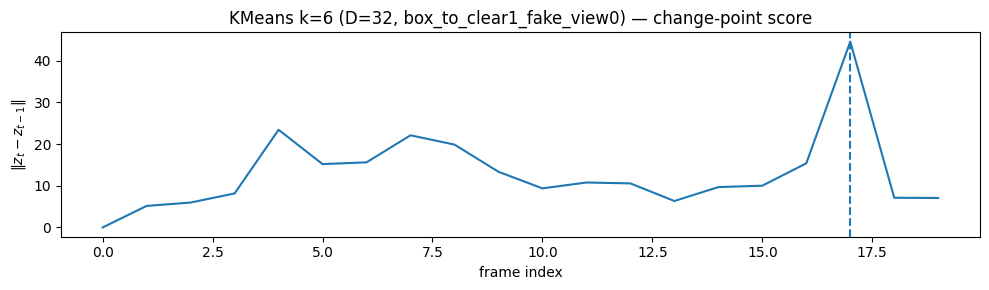

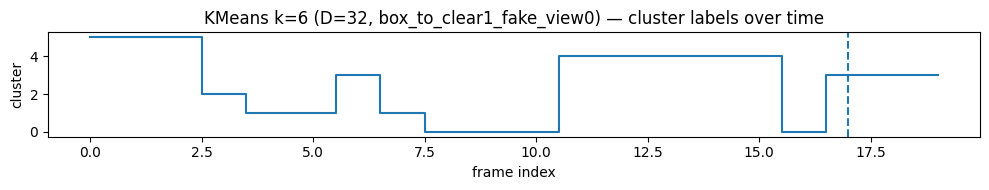

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


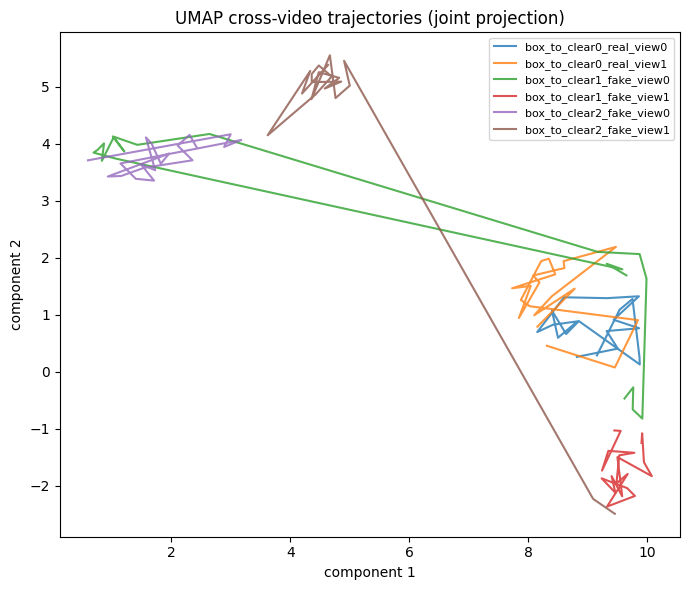

Loaded checkpoint: /workspaces/tcc/runs_tutorial/pouring_tcc_d64/checkpoint_5000.pt
Videos: 470
Flat embeddings shape: (9400, 128)

===== Dimension 64 =====
Number of videos: 470
Flat embedding matrix: (9400, 128)


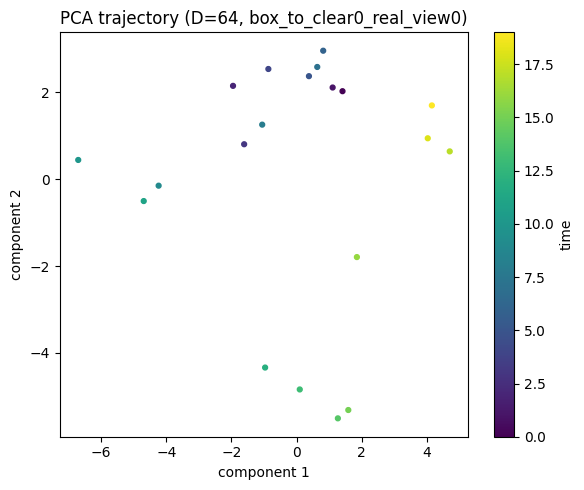

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


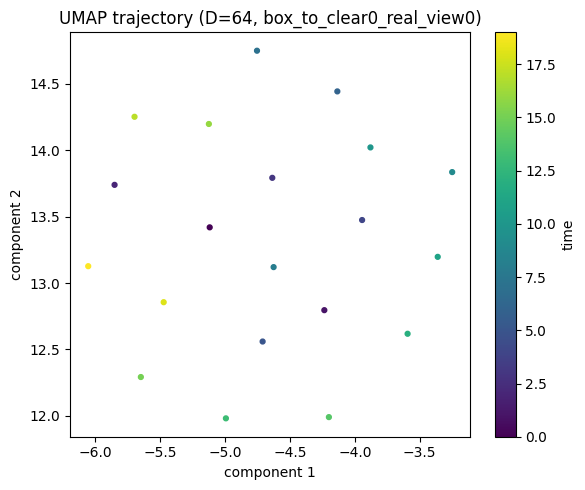

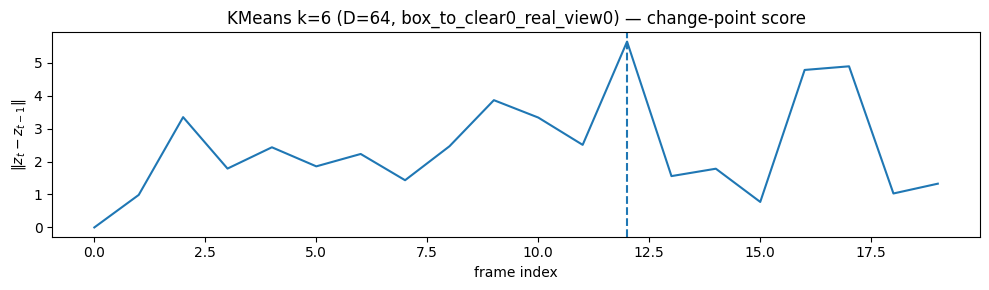

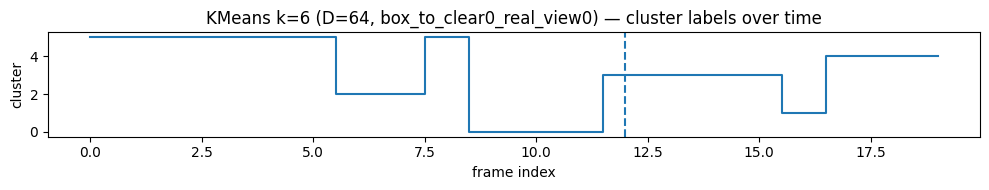

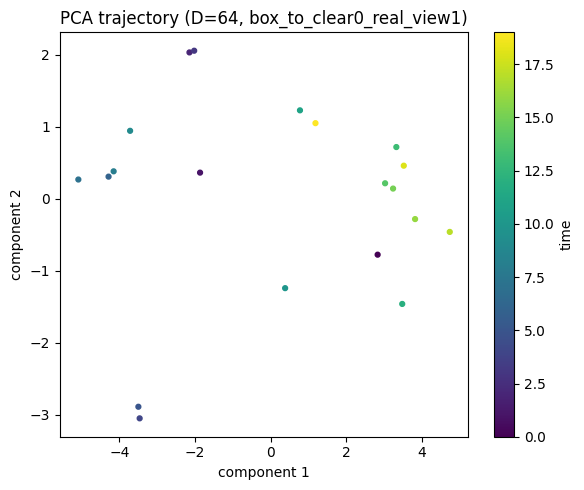

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


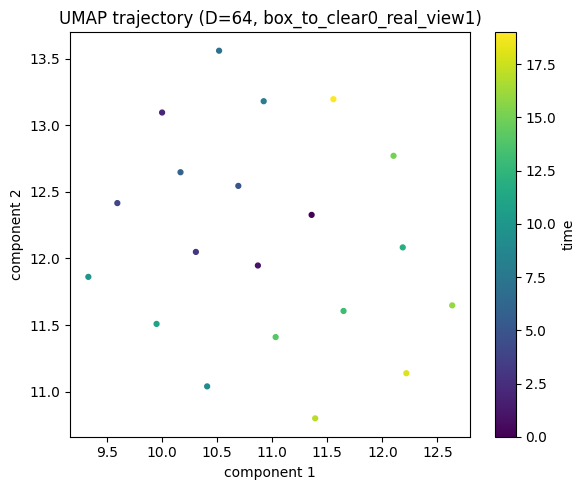

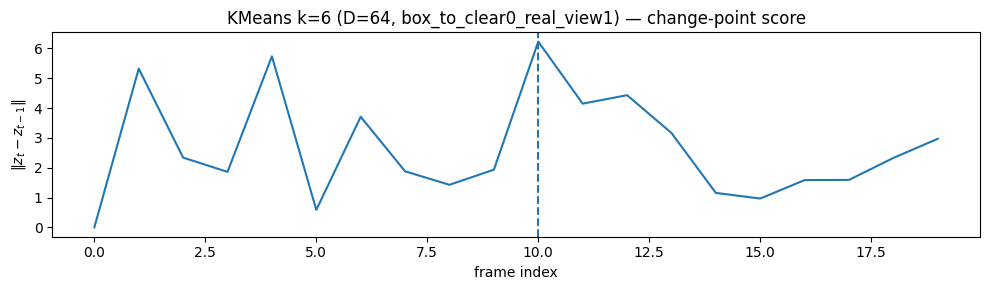

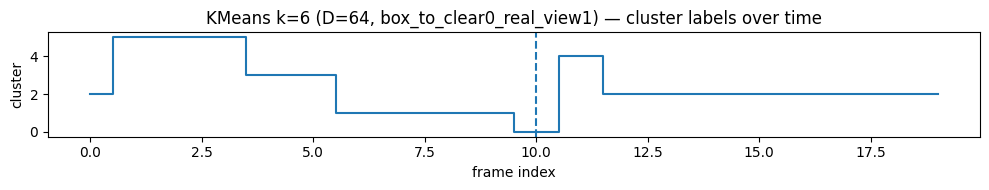

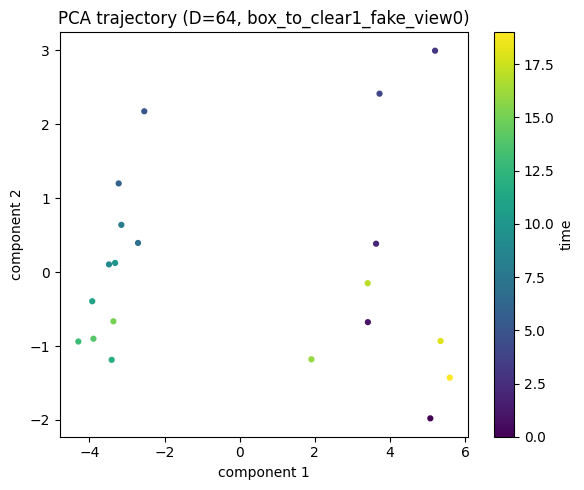

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


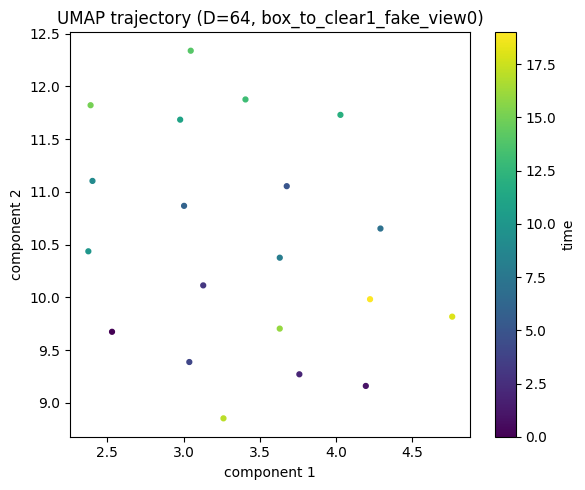

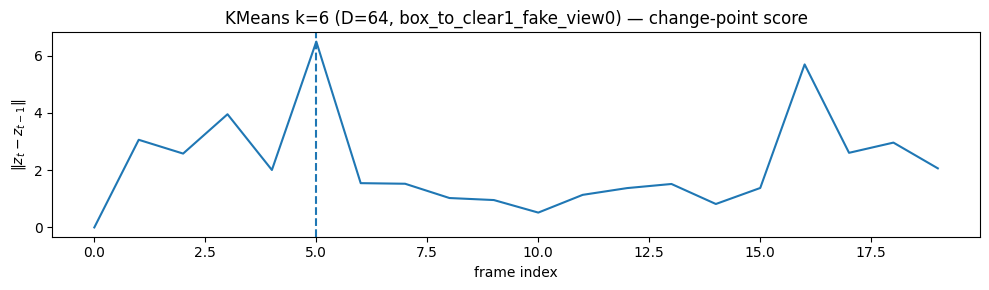

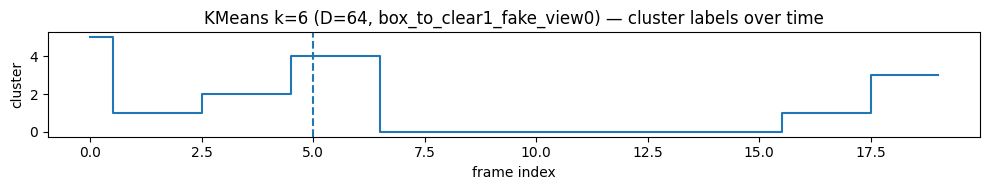

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


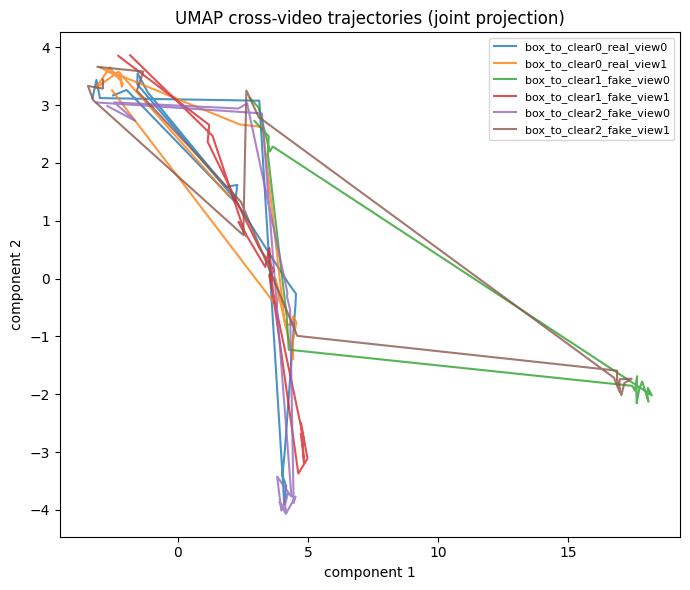

Loaded checkpoint: /workspaces/tcc/runs_tutorial/pouring_tcc_d128/checkpoint_5000.pt
Videos: 470
Flat embeddings shape: (9400, 128)

===== Dimension 128 =====
Number of videos: 470
Flat embedding matrix: (9400, 128)


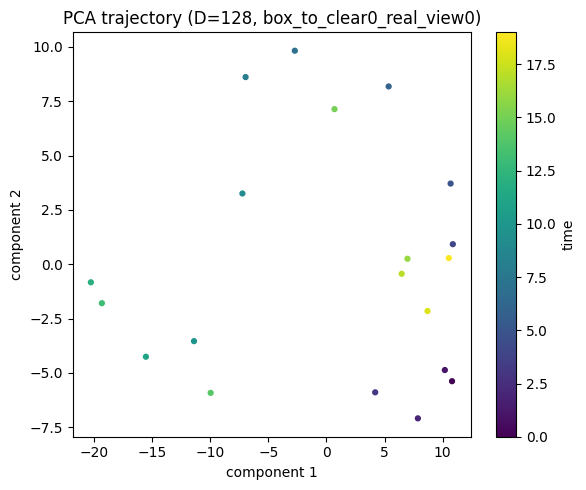

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


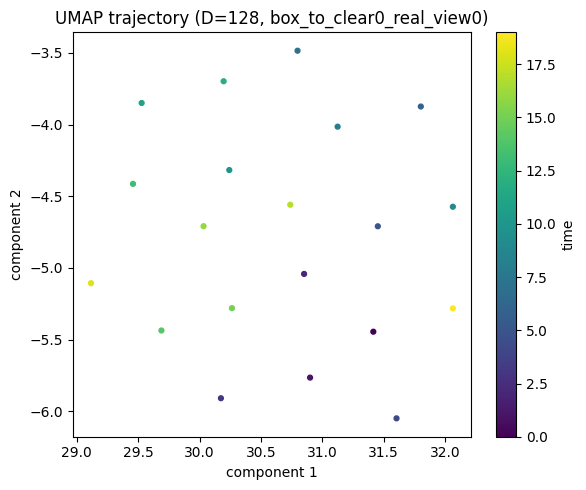

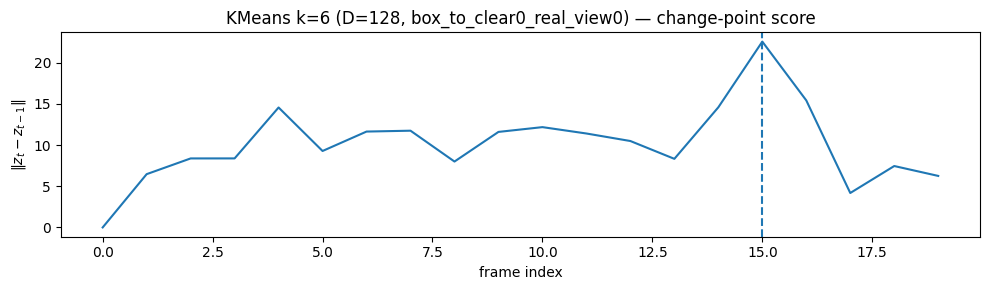

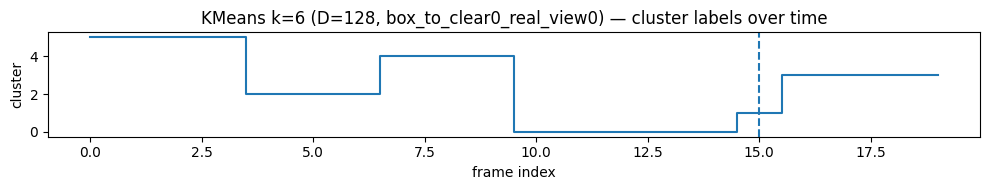

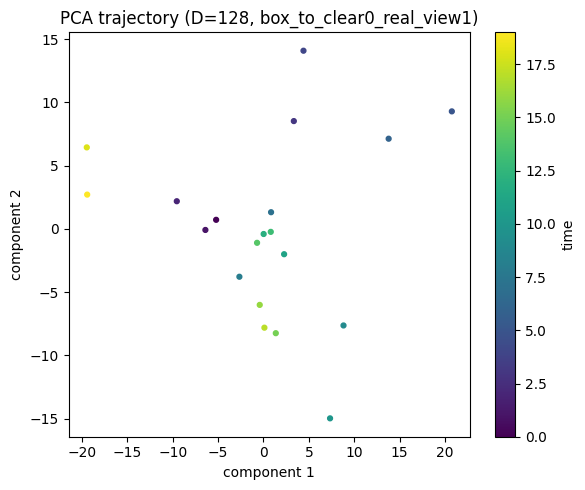

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


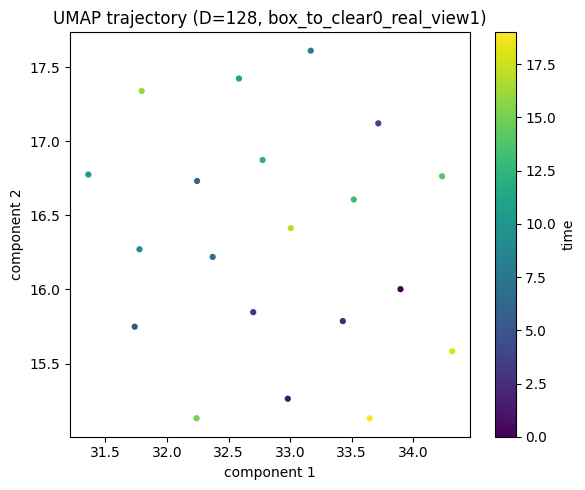

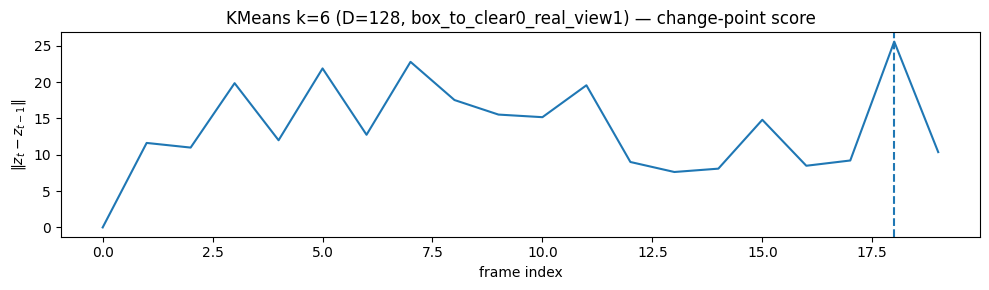

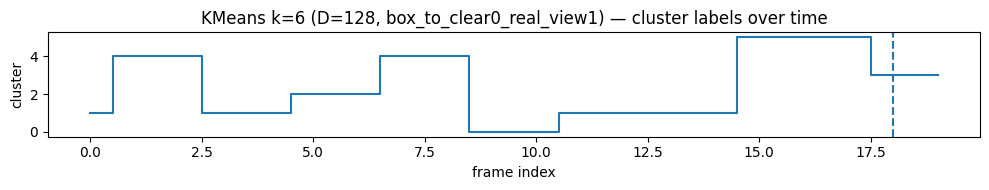

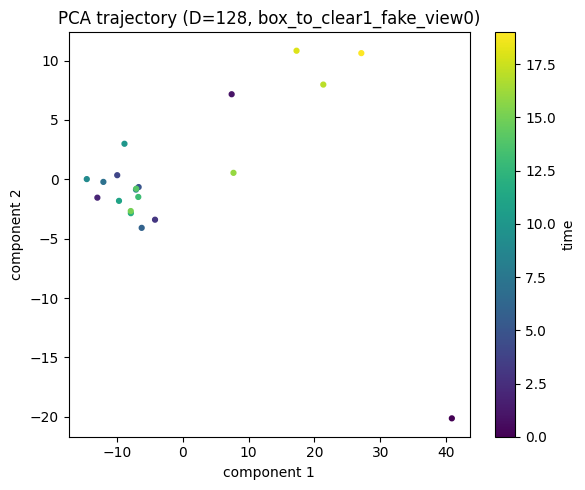

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


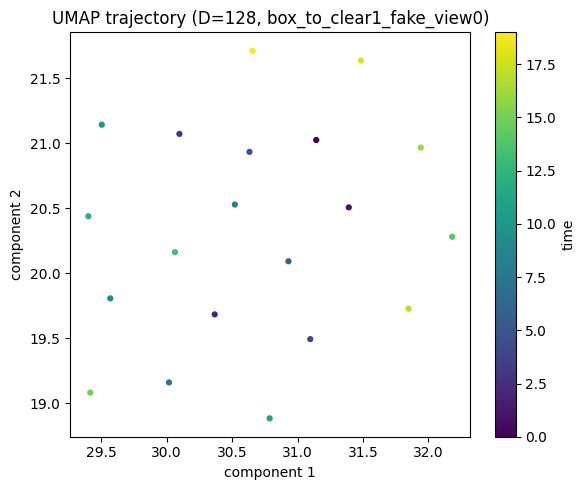

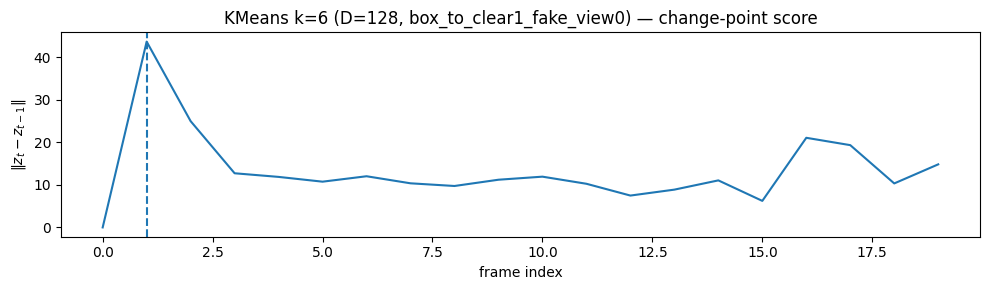

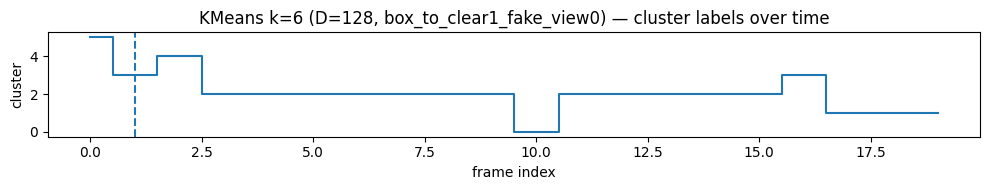

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


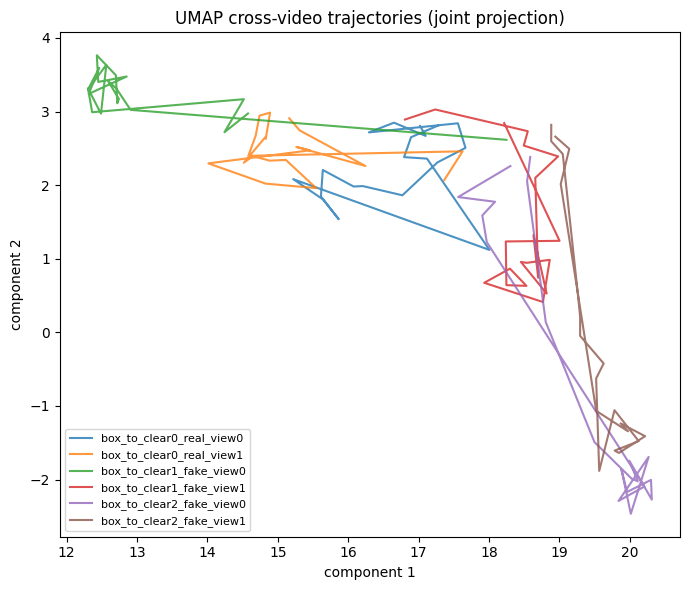

In [21]:
def run_full_analysis_for_dimension(embed_dim, max_iters=5000, split="val",
                                    max_embs=0, num_videos_to_analyze=3):
    """Run the complete analysis pipeline for one embedding dimension.

    Analyzes up to num_videos_to_analyze videos (not just the first one)
    to ensure results are not artifacts of a single video.
    """
    cfg = make_run_config(embed_dim=embed_dim, max_iters=max_iters)
    bundle = extract_embeddings_for_run(cfg, split=split, max_embs=max_embs)

    print(f"\n===== Dimension {embed_dim} =====")
    print("Number of videos:", len(bundle["embeddings_list"]))
    print("Flat embedding matrix:", bundle["embeddings"].shape)

    if len(bundle["embeddings_list"]) == 0:
        print("No embeddings found.")
        return cfg, bundle

    n_analyze = min(num_videos_to_analyze, len(bundle["embeddings_list"]))

    for vid_idx in range(n_analyze):
        Z = bundle["embeddings_list"][vid_idx]
        vid_name = bundle["names"][vid_idx] if "names" in bundle else f"video_{vid_idx}"
        tag = f"D={embed_dim}, {vid_name}"

        plot_single_trajectory(Z, method="pca", title=f"PCA trajectory ({tag})")
        if HAS_UMAP:
            plot_single_trajectory(Z, method="umap", title=f"UMAP trajectory ({tag})")

        d = change_point_scores(Z)
        boundaries, thr = detect_boundaries(d, threshold_quantile=0.98, min_gap=8)
        labels_km = cluster_kmeans(Z, k=6)
        plot_segmentation(Z, labels=labels_km, boundaries=boundaries,
                          title=f"KMeans k=6 ({tag})")

    # Cross-video overlay (joint projection)
    if HAS_UMAP and len(bundle["embeddings_list"]) > 1:
        plot_multiple_trajectories(bundle["embeddings_list"], bundle.get("names"),
                                   method="umap")

    return cfg, bundle

# Run full analysis for all three embedding dimensions
results = {}
for d in embed_dims:
    cfg_d, bundle_d = run_full_analysis_for_dimension(d, max_iters=max_iters)
    results[d] = (cfg_d, bundle_d)

## 11. Write-up questions

### Q1. TCN vs TCC
Explain, in your own words, the evolution from TCN to TCC. Include the role of the soft nearest-neighbor formulation in making cycle consistency differentiable.

### Q2. Does the learned representation encode phase?
Use your PCA and UMAP plots to justify a claim. Compare single-video trajectories with cross-video overlays.

### Q3. How well does segmentation recover phase structure?
Compare change-point detection and KMeans clustering. Do the detected boundaries align with qualitative phase transitions? Does varying $k$ change the story?

### Q4. What failure modes remain?
Examples:

- appearance variation dominating phase
- pauses causing over-segmentation
- self-similar frames across non-adjacent stages
- collapse of distinct phases into one cluster

## 12. Final checklist

Before submitting, verify that you have:

- trained at least one real TCC run on pouring
- extracted embeddings from a saved checkpoint
- produced PCA and UMAP trajectory plots for multiple videos
- produced a cross-video overlay using joint projection
- run both change-point detection and KMeans segmentation
- compared $D=32,64,128$
- written answers to all four questions (Q1\u2013Q4) in inline markdown cells, with all supporting figures embedded in the notebook

That completes the assignment.